# 01 — Data Exploration & Preprocessing

**Project:** Resume-JD Scorer — Fine-tuned DistilBERT  
**Goal of this notebook:** Load the `netsol/resume-score-details` dataset, understand the schema, clean invalid samples, normalize scores to 0-100, and save a clean DataFrame ready for training.

---

## Why this dataset?
- 1,031 resume-JD pairs labeled by GPT-4o
- Scores come from a structured rubric (macro + micro criteria)
- Gives us richer signal than simple binary match/no-match labels

## What we'll do
1. Install dependencies
2. Load the raw dataset
3. Inspect the schema
4. Filter invalid samples
5. Normalize scores to 0-100
6. Analyze score distribution
7. Save clean CSV for training


In [3]:
# Step 1 — Install dependencies
# Run this cell first every time you open this notebook in Colab
!pip install -q datasets transformers pandas numpy matplotlib seaborn

In [4]:
import json
from huggingface_hub import hf_hub_download, list_repo_files

# Load raw JSON files directly instead of using the datasets loader
from huggingface_hub import snapshot_download

snapshot_dir = snapshot_download(repo_id="netsol/resume-score-details", repo_type="dataset")
print(f"Downloaded to: {snapshot_dir}")

import os, glob
json_files = glob.glob(f"{snapshot_dir}/**/*.json", recursive=True)
print(f"Found {len(json_files)} JSON files")

# Load all samples manually
raw_samples = []
for f in json_files:
    try:
        with open(f) as fp:
            raw_samples.append(json.load(fp))
    except:
        pass

print(f"Loaded {len(raw_samples)} samples")

Fetching ... files: 0it [00:00, ?it/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--netsol--resume-score-details/snapshots/f2b49384c133beaf0a927bad6f91acc633cd0326
Found 1031 JSON files
Loaded 1031 samples


In [5]:
# Step 3 — Inspect the schema
# Look at the first sample to understand what fields are available
import json

sample = raw_samples[0]
print("Keys in a sample:")
print(list(sample.keys()))
print("\n--- Full sample (pretty printed) ---")
print(json.dumps(sample, indent=2, default=str)[:3000])  # truncate for readability

Keys in a sample:
['output', 'input', 'details']

--- Full sample (pretty printed) ---
{
  "output": {
    "justification": [
      "Candidate has over 9 years of experience in B2B sales and marketing, exceeding the 5+ years requirement. This aligns with Acme Corp's emphasis on proven experience in high-pressure sales environments.",
      "The resume shows leadership roles such as President Elect at ISA and Business Development Manager roles, indicating leadership skills and team mentoring experience, which meet the job requirement.",
      "No explicit mention of HubSpot experience, but candidate has considerable CRM experience, particularly in B2B environments, suggesting likely capability.",
      "The resume does not exhibit direct evidence of SEO experience, which impacts the micro-scoring for SEO skills."
    ],
    "scores": {
      "macro_scores": [
        {
          "criteria": "leadership",
          "score": 9
        },
        {
          "criteria": "sales experience",

In [6]:
# Confirm input field names
print("Input keys:", list(raw_samples[0]['input'].keys()))
print("Details keys:", list(raw_samples[0]['details'].keys()) if raw_samples[0].get('details') else "No details field")

Input keys: ['job_description', 'macro_dict', 'micro_dict', 'additional_info', 'minimum_requirements', 'resume']
Details keys: ['name', 'number', 'skills', 'email_id', 'location', 'projects', 'education', 'achievements', 'publications', 'certifications', 'additional_urls', 'executive_summary', 'employment_history']


In [7]:
def extract_fields(sample):
    try:
        output = sample.get("output", {})
        if isinstance(output, str):
            output = json.loads(output)

        inp = sample.get("input", {})
        if isinstance(inp, str):
            inp = json.loads(inp)

        scores = output.get("scores", {})
        aggregated = scores.get("aggregated_scores", {})

        # FIXED: correct field names from actual schema
        resume_text = inp.get("resume", "") or ""
        jd_text = inp.get("job_description", "") or ""
        macro_score = aggregated.get("macro_scores", None)
        micro_score = aggregated.get("micro_scores", None)
        valid = output.get("valid_resume_and_jd", False)

        if not valid or not resume_text.strip() or not jd_text.strip():
            return None
        if macro_score is None or micro_score is None:
            return None

        return {
            "resume": resume_text.strip(),
            "jd": jd_text.strip(),
            "macro_score": float(macro_score),
            "micro_score": float(micro_score),
        }
    except Exception as e:
        return None

In [9]:
# =============================================================
# Steps 4 & 5 — Extract fields, clean invalid samples,
# and normalize scores to 0-100
# =============================================================
# The dataset schema (confirmed from Step 3):
#   - resume lives at sample['input']['resume']
#   - job description lives at sample['input']['job_description']
#   - scores live at sample['output']['scores']['aggregated_scores']
#   - valid flag lives at sample['output']['valid_resume_and_jd']
#
# Normalization logic:
#   - macro and micro scores are on a 0-5 scale (GPT-4o rubric)
#   - we combine them 60/40 (macro weighted higher = overall fit)
#   - then rescale to 0-100 for our regression target
# =============================================================

import pandas as pd
import numpy as np
import json

def extract_fields(sample):
    """
    Extract resume, JD, and scores from a raw sample.
    Returns None if the sample is invalid or missing required fields.
    """
    try:
        output = sample.get("output", {})
        if isinstance(output, str):
            output = json.loads(output)

        inp = sample.get("input", {})
        if isinstance(inp, str):
            inp = json.loads(inp)

        scores = output.get("scores", {})
        aggregated = scores.get("aggregated_scores", {})

        resume_text = inp.get("resume", "") or ""
        jd_text = inp.get("job_description", "") or ""
        macro_score = aggregated.get("macro_scores", None)
        micro_score = aggregated.get("micro_scores", None)
        valid = output.get("valid_resume_and_jd", False)

        if not valid or not resume_text.strip() or not jd_text.strip():
            return None
        if macro_score is None or micro_score is None:
            return None

        return {
            "resume": resume_text.strip(),
            "jd": jd_text.strip(),
            "macro_score": float(macro_score),
            "micro_score": float(micro_score),
        }
    except Exception as e:
        return None


def normalize_score(macro, micro, scale=5.0):
    """
    Combine macro (60%) and micro (40%) scores and rescale to 0-100.
    Macro weighted higher because overall fit matters more than
    specific tool matches in real hiring decisions.
    """
    combined = (0.6 * macro) + (0.4 * micro)
    normalized = (combined / scale) * 100
    return round(float(np.clip(normalized, 0, 100)), 2)


# --- Extract valid samples from raw_samples ---
records = []
skipped = 0
for sample in raw_samples:
    extracted = extract_fields(sample)
    if extracted is None:
        skipped += 1
        continue
    records.append(extracted)

print(f"Valid samples: {len(records)}")
print(f"Skipped (invalid): {skipped}")

# --- Normalize scores to 0-100 and build DataFrame ---
for r in records:
    r["score"] = normalize_score(r["macro_score"], r["micro_score"])

df = pd.DataFrame(records)
print(f"\nDataFrame shape: {df.shape}")
print(df[["macro_score", "micro_score", "score"]].head(10))

Valid samples: 851
Skipped (invalid): 180

DataFrame shape: (851, 5)
   macro_score  micro_score   score
0         8.58         3.44  100.00
1         7.20         7.06  100.00
2         5.00         5.64  100.00
3         4.56         3.79   85.04
4         5.72         4.00  100.00
5         3.55         3.58   71.24
6         3.00         1.00   44.00
7         6.60         7.00  100.00
8         7.00         6.50  100.00
9         5.36         5.58  100.00


In [10]:
# =============================================================
# Fix — Detect actual score scale and re-normalize
# =============================================================
# macro_scores go up to ~9-10, not 5 as assumed
# micro_scores appear to be on a lower scale (~0-10 as well)
# We'll normalize each independently using the actual max in the dataset
# =============================================================

macro_max = df["macro_score"].max()
micro_max = df["micro_score"].max()

print(f"Macro score range: {df['macro_score'].min():.2f} - {macro_max:.2f}")
print(f"Micro score range: {df['micro_score'].min():.2f} - {micro_max:.2f}")

def normalize_score_fixed(macro, micro, macro_scale, micro_scale):
    """
    Normalize using actual observed max values per dimension.
    Combine 60/40 then scale to 0-100.
    """
    macro_norm = macro / macro_scale
    micro_norm = micro / micro_scale
    combined = (0.6 * macro_norm) + (0.4 * micro_norm)
    return round(float(np.clip(combined * 100, 0, 100)), 2)

# Re-compute scores with correct scale
df["score"] = df.apply(
    lambda r: normalize_score_fixed(r["macro_score"], r["micro_score"], macro_max, micro_max),
    axis=1
)

print(f"\nScore distribution after fix:")
print(df["score"].describe())
print(df[["macro_score", "micro_score", "score"]].head(10))

Macro score range: 0.00 - 9.55
Micro score range: 0.00 - 9.85

Score distribution after fix:
count    851.000000
mean      55.173337
std       19.291100
min        0.000000
25%       42.225000
50%       56.450000
75%       69.815000
max       98.330000
Name: score, dtype: float64
   macro_score  micro_score  score
0         8.58         3.44  67.88
1         7.20         7.06  73.91
2         5.00         5.64  54.32
3         4.56         3.79  44.04
4         5.72         4.00  52.18
5         3.55         3.58  36.84
6         3.00         1.00  22.91
7         6.60         7.00  69.89
8         7.00         6.50  70.37
9         5.36         5.58  56.34


Score distribution stats:
count    851.000000
mean      55.173337
std       19.291100
min        0.000000
25%       42.225000
50%       56.450000
75%       69.815000
max       98.330000
Name: score, dtype: float64


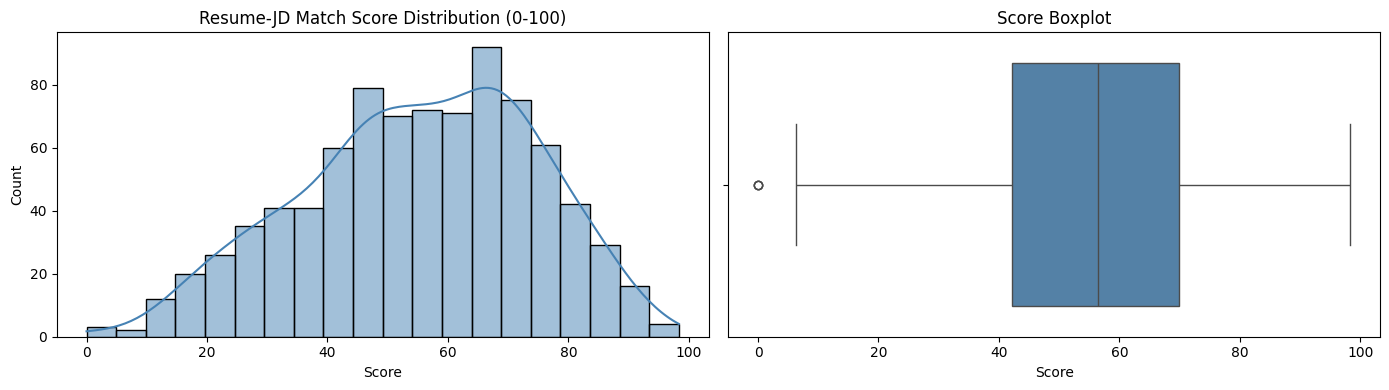


Score bracket breakdown:
  Low fit (0-33): 128 samples (15.0%)
  Mid fit (34-66): 442 samples (51.9%)
  High fit (67-100): 281 samples (33.0%)


In [11]:
# =============================================================
# Step 6 — Visualize score distribution
# =============================================================
# This tells us if the dataset is balanced or skewed.
# A heavily skewed dataset biases the model toward predicting
# the majority score range — important to know before training.
# We want a roughly normal distribution centered around 50.
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Score distribution stats:")
print(df["score"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
sns.histplot(df["score"], bins=20, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Resume-JD Match Score Distribution (0-100)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

# Boxplot to spot outliers
sns.boxplot(x=df["score"], color="steelblue", ax=axes[1])
axes[1].set_title("Score Boxplot")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

# Score bracket breakdown — useful context for the README
brackets = {
    "Low fit (0-33)":    (df["score"] <= 33).sum(),
    "Mid fit (34-66)":   ((df["score"] > 33) & (df["score"] <= 66)).sum(),
    "High fit (67-100)": (df["score"] > 66).sum(),
}
print("\nScore bracket breakdown:")
for label, count in brackets.items():
    pct = round(count / len(df) * 100, 1)
    print(f"  {label}: {count} samples ({pct}%)")

In [12]:
# =============================================================
# Step 7 — Train / Validation / Test split and save to Drive
# =============================================================
# Split: 80% train, 10% validation, 10% test
# We shuffle first (random_state=42 for reproducibility) to avoid
# any ordering bias from how the dataset was originally structured.
#
# Files are saved to Google Drive so notebooks 02 and 03
# can load them without re-running this entire pipeline.
# =============================================================

from sklearn.model_selection import train_test_split
from google.colab import drive

# Keep only the columns training needs
df_clean = df[["resume", "jd", "score"]].copy()
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

# Split: 80 / 10 / 10
train_df, temp_df = train_test_split(df_clean, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df,  test_size=0.5, random_state=42)

print(f"Train:      {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test:       {len(test_df)} samples")
print(f"Total:      {len(train_df) + len(val_df) + len(test_df)} samples")

# Mount Google Drive and save
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/TalentMatch-AI/"
import os
os.makedirs(save_path, exist_ok=True)

train_df.to_csv(f"{save_path}train.csv", index=False)
val_df.to_csv(f"{save_path}val.csv",   index=False)
test_df.to_csv(f"{save_path}test.csv", index=False)

print(f"\nSaved to Google Drive: {save_path}")
print(f"  train.csv  — {len(train_df)} rows")
print(f"  val.csv    — {len(val_df)} rows")
print(f"  test.csv   — {len(test_df)} rows")

Train:      680 samples
Validation: 85 samples
Test:       86 samples
Total:      851 samples
Mounted at /content/drive

Saved to Google Drive: /content/drive/MyDrive/TalentMatch-AI/
  train.csv  — 680 rows
  val.csv    — 85 rows
  test.csv   — 86 rows


## Summary

After this notebook you should have:
- A clear understanding of the dataset schema
- Clean train/val/test CSVs saved to Google Drive
- A score distribution plot showing how balanced the dataset is

**Next step:** Open `02_full_finetune.ipynb` to train DistilBERT using the Trainer API.
